In [6]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [13]:
import pandas as pd
import numpy as np

movie_df = pd.read_csv('../ratings_long.csv')

movie_df

,userId,movieId,rating
0,0,16,5
1,0,72,5
2,0,86,5
3,0,259,1
4,0,319,4
...,...,...,...
195,19,573,5
196,19,607,5
197,19,611,1
198,19,721,3


Burası ek olarak doldurma metodu olarak durabilir.

In [19]:
movie_df = np.full((20, 1000),fill_value=np.nan)
movie_df[np.isnan(movie_df)] = 0
movie_df

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

I did this section below the cell

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

ratings = pd.read_csv('ratings_long.csv')
train_df, test_df = train_test_split(
    ratings, test_size=0.20, random_state=315
)

n_users = 20
n_movies = 1000
n_factors = 4
learning_rate = 0.01
regularization = 0.05
epochs = 500

rng = np.random.default_rng(315)
U = rng.normal(0, 0.1, size=(n_users, n_factors))
V = rng.normal(0, 0.1, size=(n_factors, n_movies))
loss_history = []
train_records = train_df[['userId', 'movieId', 'rating']].to_numpy()

for epoch in range(epochs):
    rng.shuffle(train_records)

    for user_id, movie_id, rating in train_records:
        user_id = int(user_id)
        movie_id = int(movie_id)

        prediction = U[user_id] @ V[:, movie_id]
        error = rating - prediction
        old_user = U[user_id].copy()
        old_movie = V[:, movie_id].copy()

        U[user_id] += learning_rate * (
            error * old_movie - regularization * old_user
        )
        V[:, movie_id] += learning_rate * (
            error * old_user - regularization * old_movie
        )

    train_predictions = np.array([
        U[int(u)] @ V[:, int(m)] for u, m, _ in train_records
    ])
    train_ratings = train_records[:, 2].astype(float)
    mse = np.mean((train_ratings - train_predictions) ** 2)
    penalty = regularization * (
        np.sum(U ** 2) + np.sum(V ** 2)
    ) / len(train_records)
    loss_history.append(mse + penalty)

print('U shape:', U.shape)
print('V shape:', V.shape)
print('Tahmin matrisi shape:', (U @ V).shape)
print('İlk loss:', round(loss_history[0], 4))
print('Son loss:', round(loss_history[-1], 4))

U shape: (20, 4)
V shape: (4, 1000)
Tahmin matrisi shape: (20, 1000)
İlk loss: 11.3562
Son loss: 0.1588


Visualize The Gradient Descent

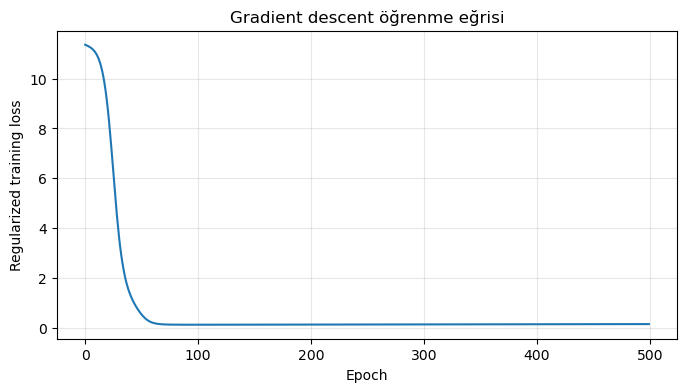

Test RMSE: 2.187
Test MAE:  1.831


In [9]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Regularized training loss')
plt.title('Gradient descent öğrenme eğrisi')
plt.grid(alpha=0.3)
plt.show()

test_predictions = np.array([
    U[int(row.userId)] @ V[:, int(row.movieId)]
    for row in test_df.itertuples()
])
test_predictions = np.clip(test_predictions, 1, 5)

print(f'Test RMSE: {mean_squared_error(test_df["rating"], test_predictions) ** 0.5:.3f}')
print(f'Test MAE:  {mean_absolute_error(test_df["rating"], test_predictions):.3f}')

In [10]:
user_id = 0
predicted_ratings = np.clip(U @ V, 1, 5)
rated_movies = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
known_movies = set(train_df['movieId'])
candidates = np.array(sorted(known_movies - rated_movies), dtype=int)

top_movies = candidates[
    np.argsort(predicted_ratings[user_id, candidates])[::-1][:10]
]

recommendations = pd.DataFrame({
    'movieId': top_movies,
    'predicted_rating': predicted_ratings[user_id, top_movies]
})
recommendations

,movieId,predicted_rating
0,697,4.205202
1,471,4.138530
2,22,3.928126
3,784,3.828795
4,777,3.819399
5,543,3.780044
6,455,3.744553
7,731,3.417241
8,758,3.403470
9,252,3.379783
